In [120]:
import matplotlib.pyplot as plt

# Compress plot resolution to keep notebook file size under 5 MB
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.bbox'] = 'tight'

In [121]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [122]:
import pandas as pd
import numpy as np

In [123]:
play_store_df = pd.read_csv('/content/drive/MyDrive/Almabetter_data/Play Store Data.csv')

In [124]:
user_reviews_df = pd.read_csv('/content/drive/MyDrive/Almabetter_data/User Reviews.csv')

In [125]:
play_store_df.shape

(10841, 13)

In [126]:
play_store_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [127]:
play_store_df.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [128]:
play_store_df1 = play_store_df.copy()

In [129]:
play_store_df1.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [130]:
play_store_df1.drop(columns=['Android Ver', 'Current Ver', 'Last Updated'], axis =1, inplace = True)

In [131]:
play_store_df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [132]:
play_store_df1['App'].duplicated().sum()

np.int64(1181)

In [133]:
pd.reset_option("display.max_rows")

In [134]:

play_store_df1.iloc[:, 0:2].duplicated().sum()

np.int64(1096)

In [135]:
play_store_df1.duplicated().sum()

np.int64(485)

In [136]:
play_store_df1.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [137]:
play_store_df1 = play_store_df1.drop_duplicates(subset = ['App', 'Category', 'Rating', 'Reviews'], keep = 'first')

In [138]:
play_store_df1.duplicated().sum()

np.int64(0)

In [139]:
play_store_df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [140]:
bad_reviews = play_store_df1[~play_store_df1['Reviews'].str.isnumeric()]

In [141]:
bad_reviews

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018"


In [142]:
play_store_df1 = play_store_df1.drop(index = bad_reviews.index).reset_index(drop = True)

In [143]:
play_store_df1.shape

(10355, 10)

In [144]:
play_store_df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [145]:
play_store_df1['Reviews'] = pd.to_numeric(play_store_df1['Reviews'], errors = 'coerce')

In [146]:
play_store_df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,int64
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [147]:
pd.set_option("display.max_rows", None)

In [148]:
play_store_df1['Size'].value_counts()

,count
Size,
Varies with device,1526
11M,188
13M,186
12M,186
14M,182
15M,174
17M,155
26M,145
16M,143


In [149]:
def convert_size(val):

  if 'M' in str(val):
    return float(val.replace('M', ''))

  elif 'k' in str(val):
    return float(val.replace('k', ''))/1024

  else:
    return None


In [150]:
pd.set_option("display.max_rows", None)

In [151]:
play_store_df1['Size'] = play_store_df1['Size'].apply(convert_size)

In [152]:
play_store_df1['Size'] = round(play_store_df1['Size'], 2)

In [153]:
median_size = play_store_df1['Size'].median()

In [154]:
play_store_df1['Size'] = play_store_df1['Size'].fillna(median_size)

In [155]:
play_store_df1['Size'].isnull().sum()

np.int64(0)

In [156]:
median_rating = play_store_df1['Rating'].median()

In [157]:
play_store_df1['Rating'] = play_store_df1['Rating'].fillna(median_rating)

In [158]:
play_store_df1.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


In [159]:
type_mode = play_store_df1['Type'].mode()[0]

In [160]:
type_mode

'Free'

In [161]:
play_store_df1['Type'] = play_store_df1['Type'].fillna(type_mode)

In [162]:
play_store_df1['Type'].value_counts()

,count
Type,
Free,9590
Paid,765


In [163]:
play_store_df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,int64
Size,float64
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [164]:
play_store_df1['Installs'].value_counts()

,count
Installs,
"1,000,000+",1488
"10,000,000+",1130
"100,000+",1129
"10,000+",1033
"1,000+",890
100+,710
"5,000,000+",683
"500,000+",517
"50,000+",474


In [165]:
def remove_plus(val):

  if '+' in str(val):
    return int(val.replace('+', '').replace(',', '').strip())
  else:
    return int(str(val).replace(',', '').strip())

In [166]:
play_store_df1['Installs'] = play_store_df1['Installs'].apply(remove_plus)

In [167]:
play_store_df1['Installs'].value_counts()

,count
Installs,
1000000,1488
10000000,1130
100000,1129
10000,1033
1000,890
100,710
5000000,683
500000,517
50000,474


In [168]:
play_store_df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,int64
Size,float64
Installs,int64
Type,object
Price,object
Content Rating,object
Genres,object


In [169]:
play_store_df1['Price'].value_counts()

,count
Price,
0,9590
$0.99,146
$2.99,125
$1.99,73
$4.99,70
$3.99,60
$1.49,46
$5.99,27
$2.49,25


In [170]:
def remove_dollar(val):
  return float(val.replace("$", '').strip())

In [171]:
play_store_df1['Price'] = play_store_df1['Price'].apply(remove_dollar)

In [172]:
play_store_df1['Price'].value_counts()

,count
Price,
0.00,9590
0.99,146
2.99,125
1.99,73
4.99,70
3.99,60
1.49,46
5.99,27
2.49,25


In [173]:
play_store_df1['Content Rating'].value_counts()

,count
Content Rating,
Everyone,8380
Teen,1146
Mature 17+,447
Everyone 10+,377
Adults only 18+,3
Unrated,2


In [174]:
play_store_df1['Content Rating'] = play_store_df1['Content Rating'].replace('Unrated', 'Everyone')

In [175]:
play_store_df1.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [176]:
play_store_df1 = play_store_df1.sort_values('Reviews', ascending= False)

In [177]:
play_store_df1 = play_store_df1.drop_duplicates('App', keep = 'first')

In [178]:
play_store_df1.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,int64
Size,float64
Installs,int64
Type,object
Price,float64
Content Rating,object
Genres,object


In [179]:
max(play_store_df1['Rating'])

5.0

In [180]:
user_reviews_df.head(10)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [181]:
user_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [182]:
user_reviews_df1 = user_reviews_df.copy()

In [183]:
user_reviews_df1.head(5)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [184]:
user_reviews_df1.shape

(64295, 5)

In [185]:
user_reviews_df1.iloc[:, 0:5].duplicated().sum()

np.int64(33616)

In [186]:
play_store_df1.shape

(9659, 10)

In [187]:
user_reviews_df1.duplicated().sum()

np.int64(33616)

In [188]:
user_reviews_df1 = user_reviews_df1.drop_duplicates(keep = 'first')

In [189]:
user_reviews_df1.shape

(30679, 5)

In [190]:
len(list(user_reviews_df1['App'].unique()))

1074

In [191]:
user_reviews_df1['App'].isnull().sum()

np.int64(0)

In [192]:
user_reviews_df1['App'].str.isnumeric().sum()

np.int64(0)

In [193]:
user_reviews_df1['App'].apply(lambda x: isinstance(x, (int, float))).sum()

np.int64(0)

In [194]:
user_reviews_df1['Translated_Review'].duplicated().sum()

np.int64(2684)

In [195]:
user_reviews_df1['Translated_Review'].isnull().sum()

np.int64(987)

In [196]:
user_reviews_df1['Sentiment'].isnull().sum()

np.int64(982)

In [197]:
user_reviews_df1['Translated_Review'].nunique()

27994

In [198]:
user_reviews_df1.isnull().sum()

,0
App,0
Translated_Review,987
Sentiment,982
Sentiment_Polarity,982
Sentiment_Subjectivity,982


In [199]:
user_reviews_df1.dropna(subset = ['Translated_Review', 'Sentiment'], inplace = True)

In [200]:
user_reviews_df1['Sentiment_Polarity'].isnull().sum()

np.int64(0)

In [201]:
user_reviews_df1['Sentiment_Subjectivity'].isnull().sum()

np.int64(0)

In [202]:
user_reviews_df1.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [203]:
user_reviews_df1[user_reviews_df1['Translated_Review'].str.isnumeric() == True]

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
44946,Fast Secure VPN,81759,Neutral,0.0,0.0


In [204]:
user_reviews_df1.drop(index= 44946, inplace = True)

In [205]:
user_reviews_df1['Translated_Review'].str.isnumeric().sum()

np.int64(0)

In [206]:
user_reviews_df1['Sentiment'].value_counts()

,count
Sentiment,
Positive,19015
Negative,6321
Neutral,4355


In [207]:
user_reviews_df1['Sentiment'].str.isnumeric().sum()

np.int64(0)

In [208]:
user_reviews_df1[['Sentiment_Polarity', 'Sentiment_Subjectivity']].describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,29691.000000,29691.000000
mean,0.188874,0.490947
std,0.355698,0.265965
min,-1.000000,0.000000
25%,0.000000,0.350000
50%,0.157143,0.514286
75%,0.422917,0.652728
max,1.000000,1.000000


In [209]:
user_reviews_df.head(5)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [210]:
play_store_df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [211]:
play_store_df1.shape

(9659, 10)

In [212]:
user_reviews_df1.shape

(29691, 5)

In [213]:
merged_df = pd.merge(play_store_df1, user_reviews_df1, on = 'App', how = 'inner')

In [214]:
merged_df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Facebook,SOCIAL,4.1,78158306,13.0,1000000000,Free,0.0,Teen,Social,"If I open link different browser, refreshes fe...",Positive,0.080096,0.343251
1,Facebook,SOCIAL,4.1,78158306,13.0,1000000000,Free,0.0,Teen,Social,I believe lot Google need slow little. There e...,Positive,0.103356,0.533796
2,Facebook,SOCIAL,4.1,78158306,13.0,1000000000,Free,0.0,Teen,Social,I know went wrong app. I issues facebook visit...,Negative,-0.366667,0.544444
3,Facebook,SOCIAL,4.1,78158306,13.0,1000000000,Free,0.0,Teen,Social,1 star can't move photos timeline post album. ...,Negative,-0.405556,0.625000
4,Facebook,SOCIAL,4.1,78158306,13.0,1000000000,Free,0.0,Teen,Social,"This used work well, past 2 months I gotten no...",Positive,0.116667,0.425000


In [215]:
merged_df.duplicated().sum()

np.int64(0)

In [216]:
merged_df.shape

(28249, 14)

In [217]:
play_store_df1.shape

(9659, 10)

In [218]:
# importing libraries for computing and generating visuals

import matplotlib.pyplot as plt
import seaborn as sns

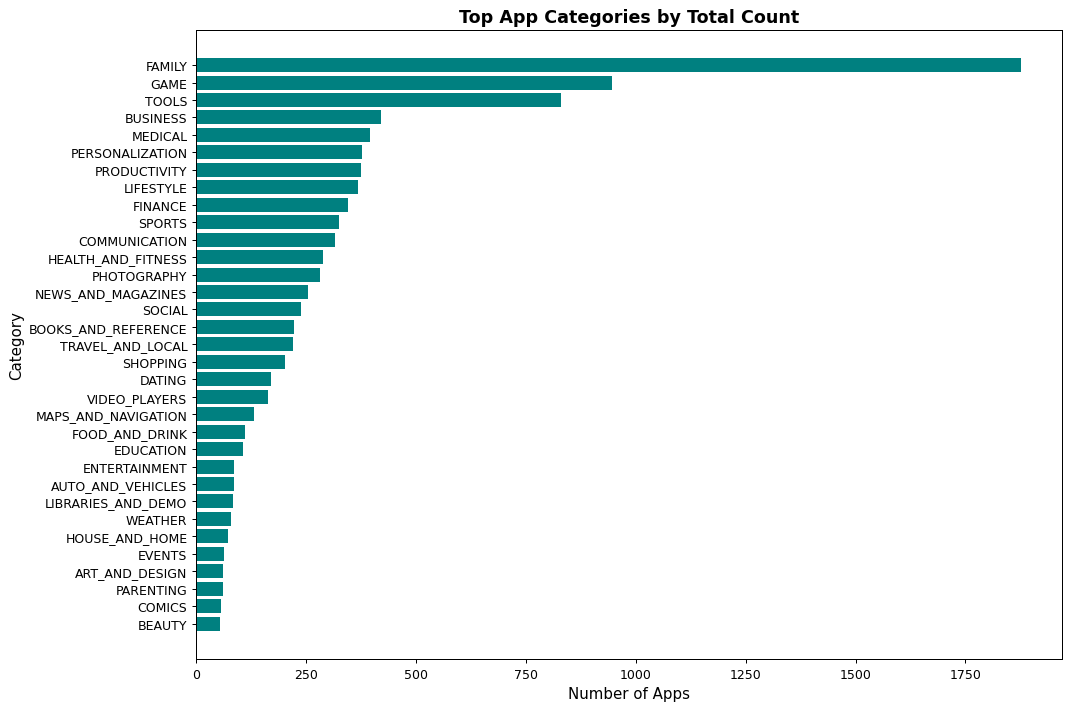

In [219]:


plt.figure(figsize=(12, 8)) # setting the figure size

# Getting the value counts on categories
category_counts = play_store_df1['Category'].value_counts()

# using matplotlib for generating horizontal bar chart and choosing color of the bars
plt.barh(category_counts.index, category_counts.values, color='teal')

plt.title('Top App Categories by Total Count', fontsize=14, fontweight='bold') # setting the title
plt.xlabel('Number of Apps', fontsize=12) # setting x-label
plt.ylabel('Category', fontsize=12) # setting y-label

# Inverting Y-axis so the highest count is at the top
plt.gca().invert_yaxis()

plt.tight_layout() # for non overlapping names, titles, etc.
plt.show()

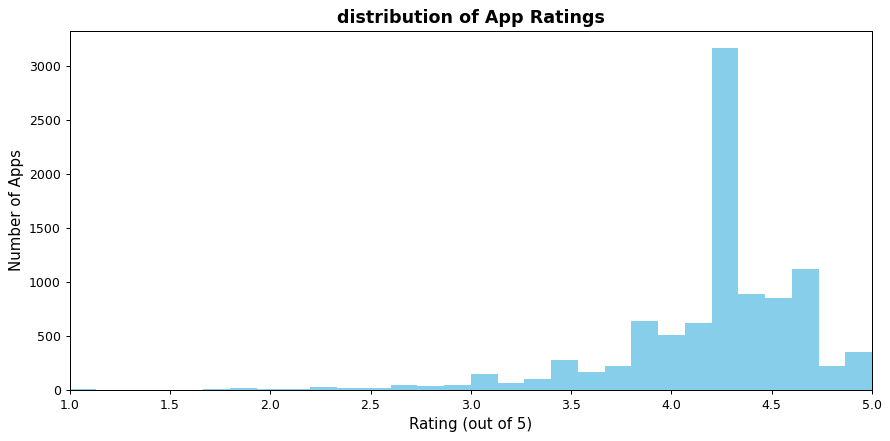

In [220]:
plt.figure(figsize = (10,5)) # setting the figure size

plt.hist(play_store_df1['Rating'], bins =30, color ='skyblue') # using matplotlib for generating histogram to show distribution of Ratings
plt.title('distribution of App Ratings', fontsize = 14, fontweight = 'bold') # setting the title
plt.xlabel('Rating (out of 5)', fontsize =12) # setting x axis-label
plt.ylabel('Number of Apps', fontsize=12) # setting y axis-label

plt.xlim(1, 5) #setting the limit on x-axis to that the values are clear and consise


plt.tight_layout() # for non overlapping names, titles, etc.
plt.show()

In [221]:
play_store_df1.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres
2246,Facebook,SOCIAL,4.1,78158306,13.0,1000000000,Free,0.0,Teen,Social
303,WhatsApp Messenger,COMMUNICATION,4.4,69119316,13.0,1000000000,Free,0.0,Everyone,Communication
2305,Instagram,SOCIAL,4.5,66577446,13.0,1000000000,Free,0.0,Teen,Social
348,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,13.0,1000000000,Free,0.0,Everyone,Communication
1662,Clash of Clans,GAME,4.6,44893888,98.0,100000000,Free,0.0,Everyone 10+,Strategy


In [222]:
type_count = play_store_df1['Type'].value_counts() # Getting the value counts on Type column

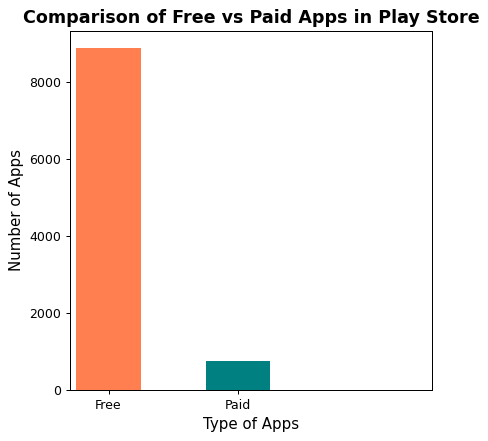

In [223]:
plt.figure(figsize = (5,5)) # setting the size of the chart

positions = [0, 0.4]

plt.bar(type_count.index, type_count.values, color=['coral', 'teal'], width = 0.5) # Generating bar chart and setting the width

plt.title('Comparison of Free vs Paid Apps in Play Store', fontsize = 14, fontweight= 'bold') # Setting the title for the chart
plt.xlabel('Type of Apps', fontsize = 12) # Setting label for x-axis
plt.ylabel('Number of Apps', fontsize = 12) # setting label  for y- axis
plt.tick_params( axis='both', color = 'black', labelcolor = 'black') # setting tick paramaters to black as I experimented with purple color

plt.xlim(-0.3, 2.5) #setting the limit on x-axis to that the values are clear and consise

plt.tight_layout() # for non overlapping names, titles, etc.

plt.show()




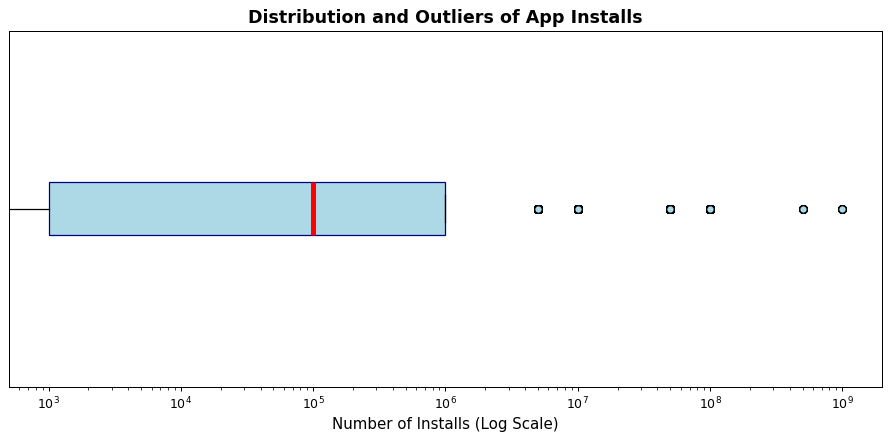

In [224]:
plt.figure(figsize= (10,5)) # setting the size of the chart


plt.boxplot(play_store_df1['Installs'], vert = False, patch_artist = True,  # generating horizontal box plot by giving vert parameter and setting patch_artist to true so that the box can be filled with color
            boxprops= {'facecolor': 'lightblue', 'color':'Navy'}, # coloring the box for appeal
            medianprops= {'color': 'red', 'linewidth' : 4}, # coloring and setting the width of median line
            flierprops={'markerfacecolor': 'lightblue'}) # filling the outliers

plt.title("Distribution and Outliers of App Installs", fontsize = 14, fontweight = 'bold')  # setting the title for the chart
plt.xlabel("Number of Installs (Log Scale)", fontsize = 12) # setting x-label of the chart

plt.xscale('log') # since the range of numbers was very high from few thousands to billions set the x axis to logarithmic scale for better diepersion
plt.yticks([]) # setting y axis ticks to none as they have no importanc here

plt.tight_layout() # for non overlapping names, titles, etc.
plt.show()

In [225]:
play_store_df1['Installs'].median()

100000.0

In [226]:
print(play_store_df1['Installs'].mean())

7798170.248162336


In [227]:
paid_apps = play_store_df1[play_store_df1['Price']>0]

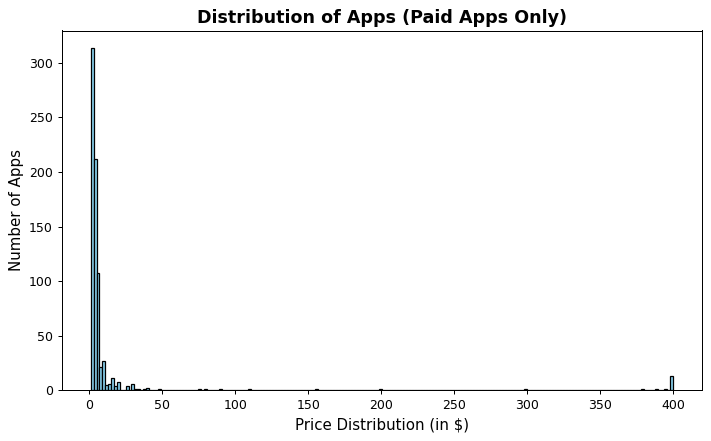

In [228]:
plt.figure(figsize = (8,5)) # setting the size of the chart


plt.hist(paid_apps['Price'], bins = 200, color ='skyblue', edgecolor = 'black') # generating histogram for the paid apps distribution and settings bins
plt.title('Distribution of Apps (Paid Apps Only)', fontsize = 14, fontweight = 'bold') # setting the title for the chart
plt.xlabel('Price Distribution (in $)', fontsize =12) # setting label  for x- axis
plt.ylabel('Number of Apps', fontsize = 12) # setting label  for y- axis

plt.tight_layout() # for non overlapping names, titles, etc.


plt.show()

In [229]:
play_store_df1.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres'],
      dtype='object')

In [230]:
category_installs = (play_store_df1.groupby('Category')['Installs'].sum()/1e9).sort_values(ascending = True)

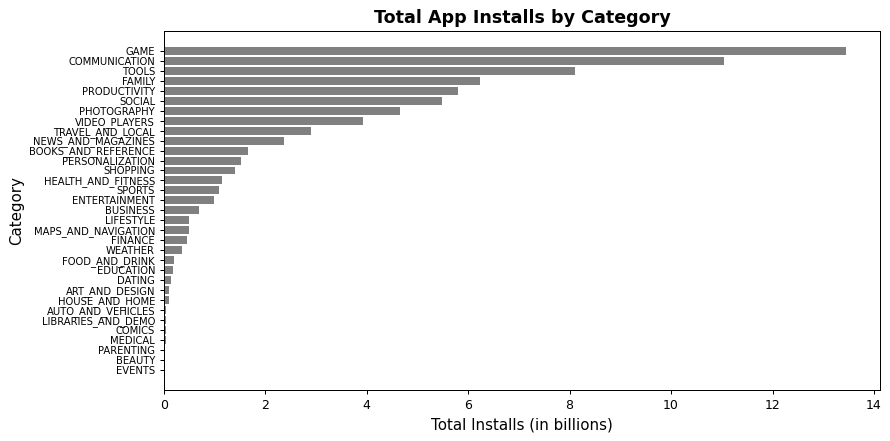

In [231]:
plt.figure(figsize= (10,5))

plt.barh(category_installs.index, category_installs.values, color = 'grey')
plt.title('Total App Installs by Category', fontsize = 14, fontweight ='bold')
plt.xlabel('Total Installs (in billions)', fontsize = 12)
plt.ylabel('Category', fontsize = 12)
plt.xticks(fontsize =10)
plt.yticks(fontsize =8)
plt.tight_layout()
plt.show()